C:\Users\user\AppData\Local\Temp\ipykernel_44440\3701761609.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("GnBu")


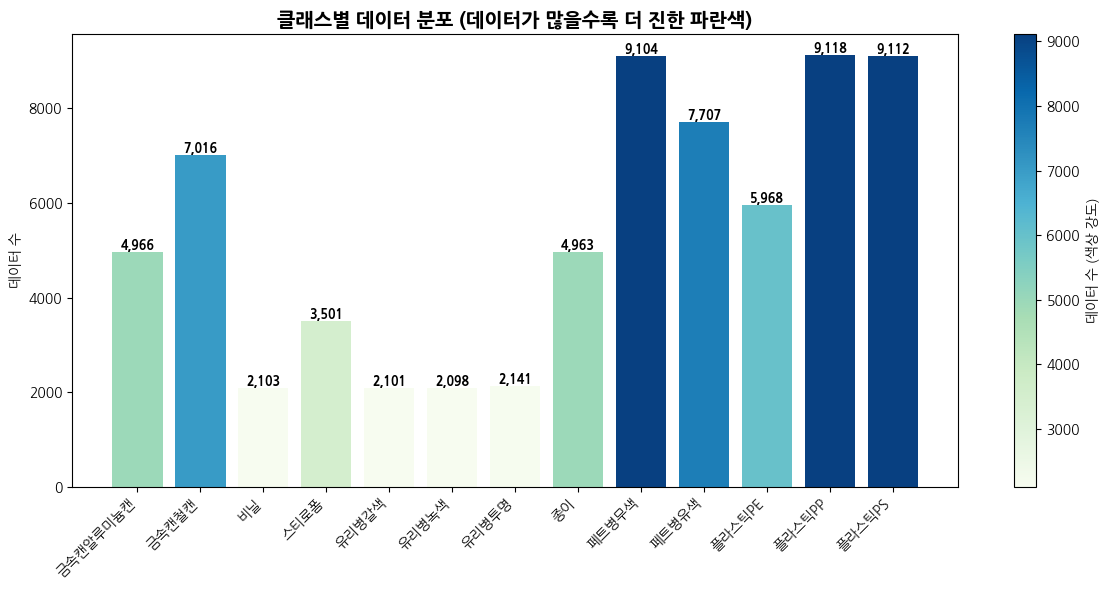

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib import cm, colors
import koreanize_matplotlib

# 데이터
class_names = [
    "금속캔알루미늄캔", "금속캔철캔", "비닐", "스티로폼",
    "유리병갈색", "유리병녹색", "유리병투명", "종이",
    "페트병무색", "페트병유색", "플라스틱PE", "플라스틱PP", "플라스틱PS"
]
data_counts = [4966, 7016, 2103, 3501, 2101, 2098, 2141, 4963, 9104, 7707, 5968, 9118, 9112]

# 값 → 색상 강도 매핑 (큰 값일수록 더 진한 파란색)
norm = colors.Normalize(vmin=min(data_counts), vmax=max(data_counts))
cmap = cm.get_cmap("GnBu")
bar_colors = [cmap(norm(v)) for v in data_counts]

# fig와 ax를 명시적으로 생성
fig, ax = plt.subplots(figsize=(12, 6))

# ax에 bar 플롯을 그림
bars = ax.bar(class_names, data_counts, color=bar_colors)

# 바 위에 값 표시
for bar, count in zip(bars, data_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{count:,}',
            ha='center', va='bottom', fontsize=9, color='black', weight='bold')

# ax를 colorbar 함수에 전달
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("데이터 수 (색상 강도)")

# ax를 사용하여 제목과 축 레이블 설정
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_title("클래스별 데이터 분포 (데이터가 많을수록 더 진한 파란색)", fontsize=14, weight='bold')
ax.set_ylabel("데이터 수")
ax.set_xlabel("")

fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
plt.show()